# Baseline CNN Training

This notebook trains a custom CNN baseline on the DeepWeeds dataset using the official split files from the DeepWeeds repository.

In [1]:
import os
import copy
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

BASE_DIR = os.path.expanduser("~/Developer/curtin/NNSML/datasets/DeepWeeds")
IMAGES_DIR = os.path.join(BASE_DIR, "images")
LABELS_DIR = os.path.join(BASE_DIR, "labels")

TRAIN_CSV = os.path.join(LABELS_DIR, "train_subset0.csv")
VAL_CSV = os.path.join(LABELS_DIR, "val_subset0.csv")
TEST_CSV = os.path.join(LABELS_DIR, "test_subset0.csv")

RESULTS_DIR = "../results"
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
TABLES_DIR = os.path.join(RESULTS_DIR, "tables")
CHECKPOINTS_DIR = os.path.join(RESULTS_DIR, "checkpoints")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

CLASS_NAMES = [
    "Chinee Apple",
    "Lantana",
    "Parkinsonia",
    "Parthenium",
    "Prickly Acacia",
    "Rubber Vine",
    "Siam Weed",
    "Snake Weed",
    "Negatives",
]

NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

Using device: cpu


In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

for split_df in [train_df, val_df, test_df]:
    split_df["image_path"] = split_df["Filename"].apply(lambda x: os.path.join(IMAGES_DIR, x))
    split_df["label"] = split_df["Label"].astype(int)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Train: (10501, 4)
Val: (3501, 4)
Test: (3507, 4)


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [6]:
class DeepWeedsDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
train_dataset = DeepWeedsDataset(train_df, transform=train_transform)
val_dataset = DeepWeedsDataset(val_df, transform=eval_transform)
test_dataset = DeepWeedsDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 329
Val batches: 110
Test batches: 110


In [9]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Sample labels: [4, 8, 8, 8, 8, 7, 5, 4, 7, 8]


In [10]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return epoch_loss, epoch_acc, precision, recall, f1

In [13]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return epoch_loss, epoch_acc, precision, recall, f1, all_labels, all_preds

In [14]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_f1 = -1.0

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), os.path.join(CHECKPOINTS_DIR, "baseline_cnn_best.pth"))

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
    )

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed/60:.2f} minutes")

Epoch [1/15] | Train Loss: 2.6916, Train Acc: 0.4897, Train F1: 0.1172 | Val Loss: 1.5960, Val Acc: 0.5201, Val F1: 0.0760
Epoch [2/15] | Train Loss: 1.5233, Train Acc: 0.5168, Train F1: 0.1256 | Val Loss: 1.3481, Val Acc: 0.5239, Val F1: 0.0931
Epoch [3/15] | Train Loss: 1.4556, Train Acc: 0.5220, Train F1: 0.1305 | Val Loss: 1.4166, Val Acc: 0.5207, Val F1: 0.0781
Epoch [4/15] | Train Loss: 1.4267, Train Acc: 0.5250, Train F1: 0.1386 | Val Loss: 1.3346, Val Acc: 0.5213, Val F1: 0.0812
Epoch [5/15] | Train Loss: 1.4235, Train Acc: 0.5229, Train F1: 0.1335 | Val Loss: 1.3059, Val Acc: 0.5204, Val F1: 0.0781
Epoch [6/15] | Train Loss: 1.4201, Train Acc: 0.5220, Train F1: 0.1202 | Val Loss: 1.3498, Val Acc: 0.5367, Val F1: 0.1283
Epoch [7/15] | Train Loss: 1.4029, Train Acc: 0.5257, Train F1: 0.1386 | Val Loss: 1.2776, Val Acc: 0.5364, Val F1: 0.1283
Epoch [8/15] | Train Loss: 1.3859, Train Acc: 0.5297, Train F1: 0.1492 | Val Loss: 1.2348, Val Acc: 0.5170, Val F1: 0.1293
Epoch [9/15] | T

In [15]:
model.load_state_dict(best_model_wts)
print("Loaded best model based on validation macro F1.")

Loaded best model based on validation macro F1.


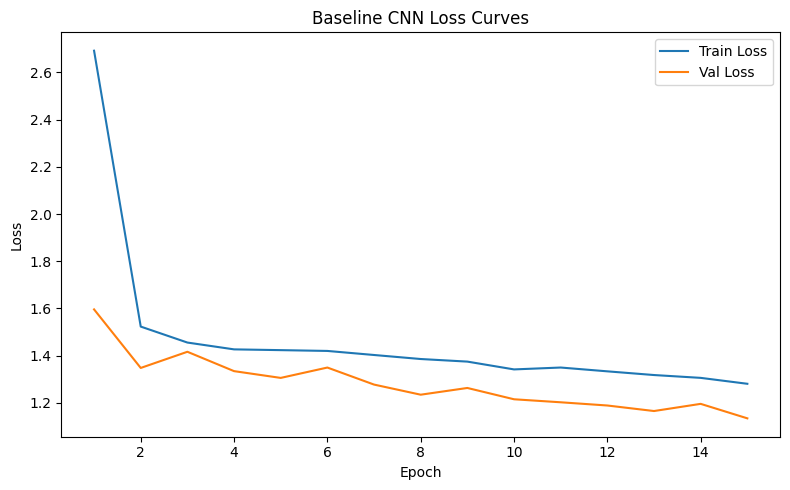

In [16]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred = evaluate(
    model, test_loader, criterion, DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro Precision: {test_prec:.4f}")
print(f"Test Macro Recall: {test_rec:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")

Test Loss: 1.1159
Test Accuracy: 0.5723
Test Macro Precision: 0.5756
Test Macro Recall: 0.2353
Test Macro F1: 0.2181


In [18]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
Chinee Apple,0.000000,0.000000,0.000000,226.000000
Lantana,0.428571,0.028169,0.052863,213.000000
Parkinsonia,0.463415,0.642512,0.538462,207.000000
Parthenium,0.700000,0.034146,0.065116,205.000000
Prickly Acacia,0.677165,0.403756,0.505882,213.000000
Rubber Vine,1.000000,0.024752,0.048309,202.000000
Siam Weed,0.333333,0.004651,0.009174,215.000000
Snake Weed,1.000000,0.009804,0.019417,204.000000
Negatives,0.577640,0.969813,0.724032,1822.000000
accuracy,0.572284,0.572284,0.572284,0.572284


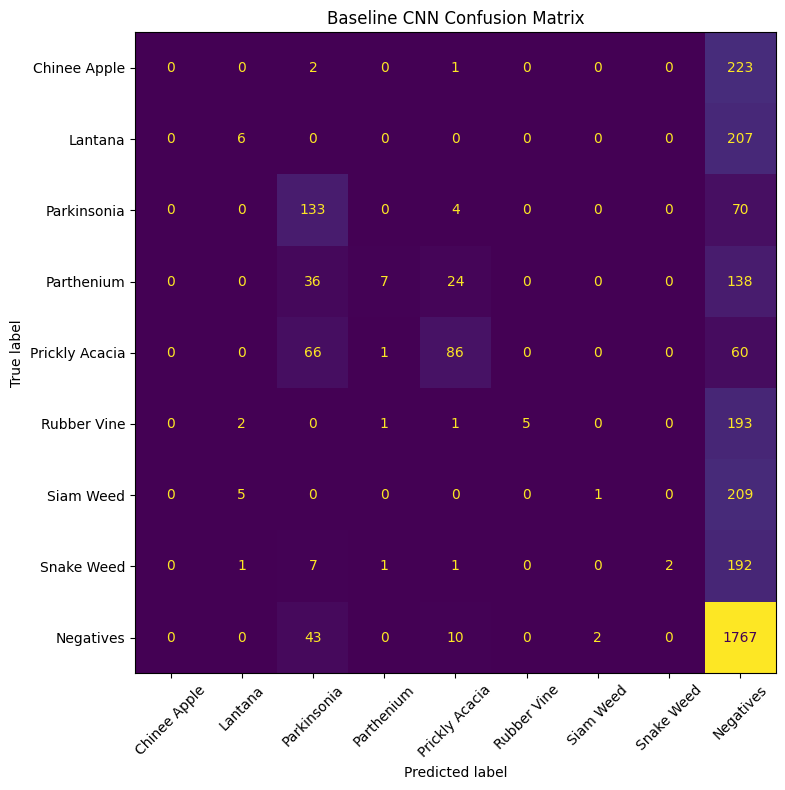

In [19]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Baseline CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [20]:
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(TABLES_DIR, "baseline_cnn_history.csv"), index=False)

report_df.to_csv(os.path.join(TABLES_DIR, "baseline_cnn_classification_report.csv"))

np.savetxt(
    os.path.join(TABLES_DIR, "baseline_cnn_confusion_matrix.csv"),
    cm,
    delimiter=",",
    fmt="%d"
)

summary_df = pd.DataFrame([{
    "model": "BaselineCNN",
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_val_f1": best_val_f1,
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "test_macro_precision": test_prec,
    "test_macro_recall": test_rec,
    "test_macro_f1": test_f1,
    "training_time_minutes": elapsed / 60,
}])

summary_df.to_csv(os.path.join(TABLES_DIR, "baseline_cnn_summary.csv"), index=False)

print("Saved baseline outputs.")

Saved baseline outputs.


## Baseline CNN Observations

- The baseline CNN achieved a test accuracy of 0.5723, but the test macro F1-score was much lower at 0.2181.
- This gap shows that overall accuracy is misleading for this dataset because the class distribution is highly imbalanced.
- The confusion matrix shows that the model predicts the Negatives class very frequently, and many weed-species samples are misclassified as Negatives.
- The model performed relatively better on Parkinsonia and Prickly Acacia, but recall was extremely poor for several classes including Chinee Apple, Siam Weed, Snake Weed, and Rubber Vine.
- Training and validation loss decreased steadily, so the main problem appears to be class imbalance and limited feature quality rather than unstable optimization.
- These results provide a strong justification for trying transfer learning in the next experiment.